In [3]:
import torch
import torch.nn as nn

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

class FCNet(nn.Module):
    """Fully connected layers with batch-norm, LeakyReLU, and dropout."""
    def __init__(self, input_dim, output_dim, n_fc=6, dropout_p=0.5): 
        super().__init__()
        hidden_dims = [max(256, input_dim // (2 ** (i + 1))) for i in range(n_fc - 1)]
        dims = [input_dim] + hidden_dims + [output_dim]

        layers = []
        for i in range(len(dims) - 1):
            layers.append(nn.Linear(dims[i], dims[i + 1]))
            if i < len(dims) - 2:
                layers += [
                    nn.BatchNorm1d(dims[i + 1]),
                    nn.LeakyReLU(0.01, inplace=True),
                    nn.Dropout(p=dropout_p)
                ]
        self.net = nn.Sequential(*layers)

    def forward(self, x):
        return self.net(x)



if __name__ == "__main__":
    model = FCNet(input_dim = 300, output_dim=256).to(device)
    v = torch.randn(2, 300).to(device)
    y = model(v)
    print("Input:", v.shape)
    print("Output:", y.shape)



Input: torch.Size([2, 300])
Output: torch.Size([2, 256])


In [81]:
import os
from sklearn.model_selection import train_test_split
import random
import pandas as pd
import numpy as np
import torch 

input_path =  r"C:\Users\mhenr\Documents\Github\spectrometer-nn\holePunch\Training_Diplex_Cookie_Batch_500_500f_1\Training_Diplex_Cookie_Batch_500_500f_1\geometries"
input_files = [f for f in os.listdir(input_path) if f.endswith('.csv')]
output_path = r"C:\Users\mhenr\Documents\Github\spectrometer-nn\holePunch\Training_Diplex_Cookie_Batch_500_500f_1\Training_Diplex_Cookie_Batch_500_500f_1\QR_S_Data"
output_files = [f for f in os.listdir(output_path) if f.endswith('.csv')]


def add_to_data(input_path, output_path):
  for f in os.listdir(input_path):
      if f.endswith('.csv'):
          input_files.append(f)

  for f in os.listdir(output_path):
      if f.endswith('.csv'):
          output_files.append(f)


input_path =  r"C:\Users\mhenr\Documents\Github\spectrometer-nn\holePunch\Training_Diplex_Cookie_Batch_500_500f_2\Training_Diplex_Cookie_Batch_500_500f_2\geometries"
output_path = r"C:\Users\mhenr\Documents\Github\spectrometer-nn\holePunch\Training_Diplex_Cookie_Batch_500_500f_2\Training_Diplex_Cookie_Batch_500_500f_2\son_files\QR_S_Data"
add_to_data(input_path, output_path)

input_path2 = r"C:\Users\mhenr\Documents\Github\spectrometer-nn\holePunch\Training_Diplex_Cookie_Batch_500_500f_0\Training_Diplex_Cookie_Batch_500_500f_0\geometries"
output_path2 = r"C:\Users\mhenr\Documents\Github\spectrometer-nn\holePunch\Training_Diplex_Cookie_Batch_500_500f_0\Training_Diplex_Cookie_Batch_500_500f_0\son_files\QR_S_Data"


data_pairs = list(zip(input_files, output_files))


train_pairs, temp_pairs = train_test_split(
    data_pairs, test_size=0.20, random_state=42, shuffle=True
)

val_pairs, test_pairs = train_test_split(
    temp_pairs, test_size=0.50, random_state=42, shuffle=True
)

train_x, train_y = zip(*train_pairs)
val_x, val_y = zip(*val_pairs)
test_x, test_y = zip(*test_pairs)


def files_to_tensor(x_paths, y_paths, n=3):
    all_x = []
    all_y = []
    
    num_intervals = 2 ** n
    
    for x_p, y_p in zip(x_paths, y_paths):
        # --- Process Input (Geometry) ---
        # Each file becomes a 300-element vector (100 points * 3 features)
        x_data = pd.read_csv(os.path.join(input_path, x_p), header=None).T.values
        all_x.append(x_data.flatten())
        
        # --- Process Output (Frequency Sweep) ---
        df = pd.read_csv(os.path.join(output_path,y_p), sep=",", skiprows=1)
        # Clean non-numeric rows
        df = df[pd.to_numeric(df.iloc[:, 0], errors="coerce").notna()]
        
        freqs = df.iloc[:, 0].astype(float).to_numpy()
        data  = df.iloc[:, 1:33].astype(float).to_numpy() # 32 columns of data

        # Define sampling points across the frequency spectrum
        edges   = np.linspace(freqs.min(), freqs.max(), num_intervals + 1)
        centers = 0.5 * (edges[:-1] + edges[1:])

        # Find the index of the frequency closest to each center
        # 
        idxs = np.abs(freqs[:, None] - centers[None, :]).argmin(axis=0)
        
        # Select those specific rows and flatten
        y_data = data[idxs].flatten()
        all_y.append(y_data)
        
        # shuffled_order = np.random.permutation(100)
        # augmented_data= x_data[shuffled_order, :]
        # all_x.append(augmented_data.T.flatten())
        # all_y.append(y_data)

    
    return torch.tensor(np.array(all_x), dtype=torch.float32), \
           torch.tensor(np.array(all_y), dtype=torch.float32)

# Create your final tensors
train_X, train_Y = files_to_tensor(train_x, train_y)
val_X, val_Y = files_to_tensor(val_x, val_y)
test_X, test_Y = files_to_tensor(test_x, test_y)

print(f"Final Training Tensor Shape: {train_X.shape}") # Should be [1600, 300]


Final Training Tensor Shape: torch.Size([5600, 300])


In [3]:
#normalizing the data

x_min = train_X.min(dim=0, keepdim=True)[0]
x_max = train_X.max(dim=0, keepdim=True)[0]

# 2. Add a tiny constant (epsilon) to prevent division by zero 
# (in case a coordinate is exactly the same in every file)
eps = 1e-7

# 3. Apply the transformation: (x - min) / (max - min)
train_X = (train_X - x_min) / (x_max - x_min + eps)
val_X   = (val_X - x_min) / (x_max - x_min + eps)
test_X  = (test_X - x_min) / (x_max - x_min + eps)

In [5]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import TensorDataset, DataLoader
import matplotlib.pyplot as plt

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")



train_ds = TensorDataset(train_X, train_Y)
val_ds = TensorDataset(val_X, val_Y)

train_loader= DataLoader(train_ds, batch_size = 32,shuffle = True )
val_loader = DataLoader(val_ds, batch_size=32)

# # === 1. Load data ===
# train_loader, val_loader, dataset = build_loaders(
#     data_root = "."  ,
#     n=1,#modify this one for higher dim output
#     batch_size=4,
#     test_ratio=0.1,  # 9:1 split
#     seed=42
# )

# === 2. Build model ===
model = FCNet(
    input_dim = 300,
    output_dim = 256,
    n_fc=6,
    dropout_p=0.3
).to(device)

criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=1e-3, weight_decay= 1e-4)
scheduler = optim.lr_scheduler.ExponentialLR(optimizer, gamma=0.98)

best_val_loss = float('inf')
patience = 100
no_improve_epochs = 0
num_epochs = 1000

train_losses, val_losses = [], []

# === 2. Training loop ===
for epoch in range(num_epochs):
    model.train()
    train_loss = 0.0
    for x, y in train_loader:
        x, y = x.to(device), y.to(device)
        optimizer.zero_grad()
        out = model(x)
        loss = criterion(out, y)
        loss.backward()
        optimizer.step()
        train_loss += loss.item() * x.size(0)

    train_loss /= len(train_loader.dataset)
    train_losses.append(train_loss)

    # === Validation ===
    model.eval()
    val_loss = 0.0
    with torch.no_grad():
        for x, y in val_loader:
            x, y = x.to(device), y.to(device)
            out = model(x)
            loss = criterion(out, y)
            val_loss += loss.item() * x.size(0)

    val_loss /= len(val_loader.dataset)
    val_losses.append(val_loss)

    scheduler.step()

    print(f"Epoch {epoch:03d} | Train Loss: {train_loss:.6f} | Val Loss: {val_loss:.6f} | LR: {scheduler.get_last_lr()[0]:.2e}")

    # === Early stopping ===
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        no_improve_epochs = 0
        torch.save(model.state_dict(), "best_model.pt")
    else:
        no_improve_epochs += 1
        if no_improve_epochs >= patience:
            print("Early stopping triggered.")
            break

print("Training done. Best validation loss:", best_val_loss)



Epoch 000 | Train Loss: 2988.736816 | Val Loss: 2616.249865 | LR: 9.80e-04
Epoch 001 | Train Loss: 2607.884293 | Val Loss: 2480.171622 | LR: 9.60e-04
Epoch 002 | Train Loss: 2457.687376 | Val Loss: 2344.457363 | LR: 9.41e-04
Epoch 003 | Train Loss: 2293.564422 | Val Loss: 2223.461203 | LR: 9.22e-04
Epoch 004 | Train Loss: 2165.133241 | Val Loss: 2143.055772 | LR: 9.04e-04
Epoch 005 | Train Loss: 2085.627716 | Val Loss: 2113.785935 | LR: 8.86e-04
Epoch 006 | Train Loss: 2037.317308 | Val Loss: 2086.894706 | LR: 8.68e-04
Epoch 007 | Train Loss: 1985.195693 | Val Loss: 2051.208058 | LR: 8.51e-04
Epoch 008 | Train Loss: 1951.185332 | Val Loss: 2022.741840 | LR: 8.34e-04
Epoch 009 | Train Loss: 1922.040257 | Val Loss: 2025.802800 | LR: 8.17e-04
Epoch 010 | Train Loss: 1909.896139 | Val Loss: 2009.597373 | LR: 8.01e-04
Epoch 011 | Train Loss: 1873.755426 | Val Loss: 2000.006586 | LR: 7.85e-04
Epoch 012 | Train Loss: 1864.099481 | Val Loss: 1958.461959 | LR: 7.69e-04
Epoch 013 | Train Loss: 1

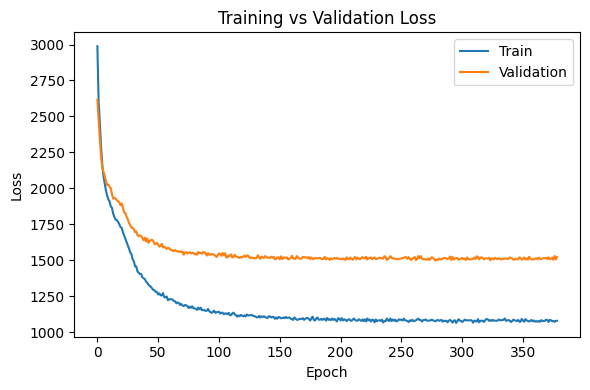

In [6]:
# === 3. Plot losses ===
plt.figure(figsize=(6,4))
plt.plot(train_losses, label='Train')
plt.plot(val_losses, label='Validation')
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.title("Training vs Validation Loss")
plt.tight_layout()
plt.show()

In [8]:
import os 
import pandas as pd
directory = r"C:\Users\mhenr\Documents\Github\spectrometer-nn\holePunch\Training_Diplex_Cookie_Batch_500_500f_1\Training_Diplex_Cookie_Batch_500_500f_1\geometries"
# directory = r"/holePunch/Training_Diplex_Cookie_Batch_500_500f_1/Training_Diplex_Cookie_Batch_500_500f_1/geometries"
files = [f for f in os.listdir(directory) if f.endswith('.csv')]

input_data = []
# for f in os.listdir(directory):
#   path = directory + f

path = r"C:\Users\mhenr\Documents\Github\spectrometer-nn\holePunch\Training_Diplex_Cookie_Batch_500_500f_1\Training_Diplex_Cookie_Batch_500_500f_1\geometries\dip_cookie_geom_500_0001.csv"


for f in os.listdir(directory):
  path = directory + "/" + f
  df = pd.read_csv(path, header=None)
  df = df.T
  for i in range(100):
    input_data.append(df.loc[i].tolist())
# print(df.columns)
# for column in df.columns:
#   data = [df[0][column], df[1][column], df[2][column]]
#   print(data)



KeyboardInterrupt: 

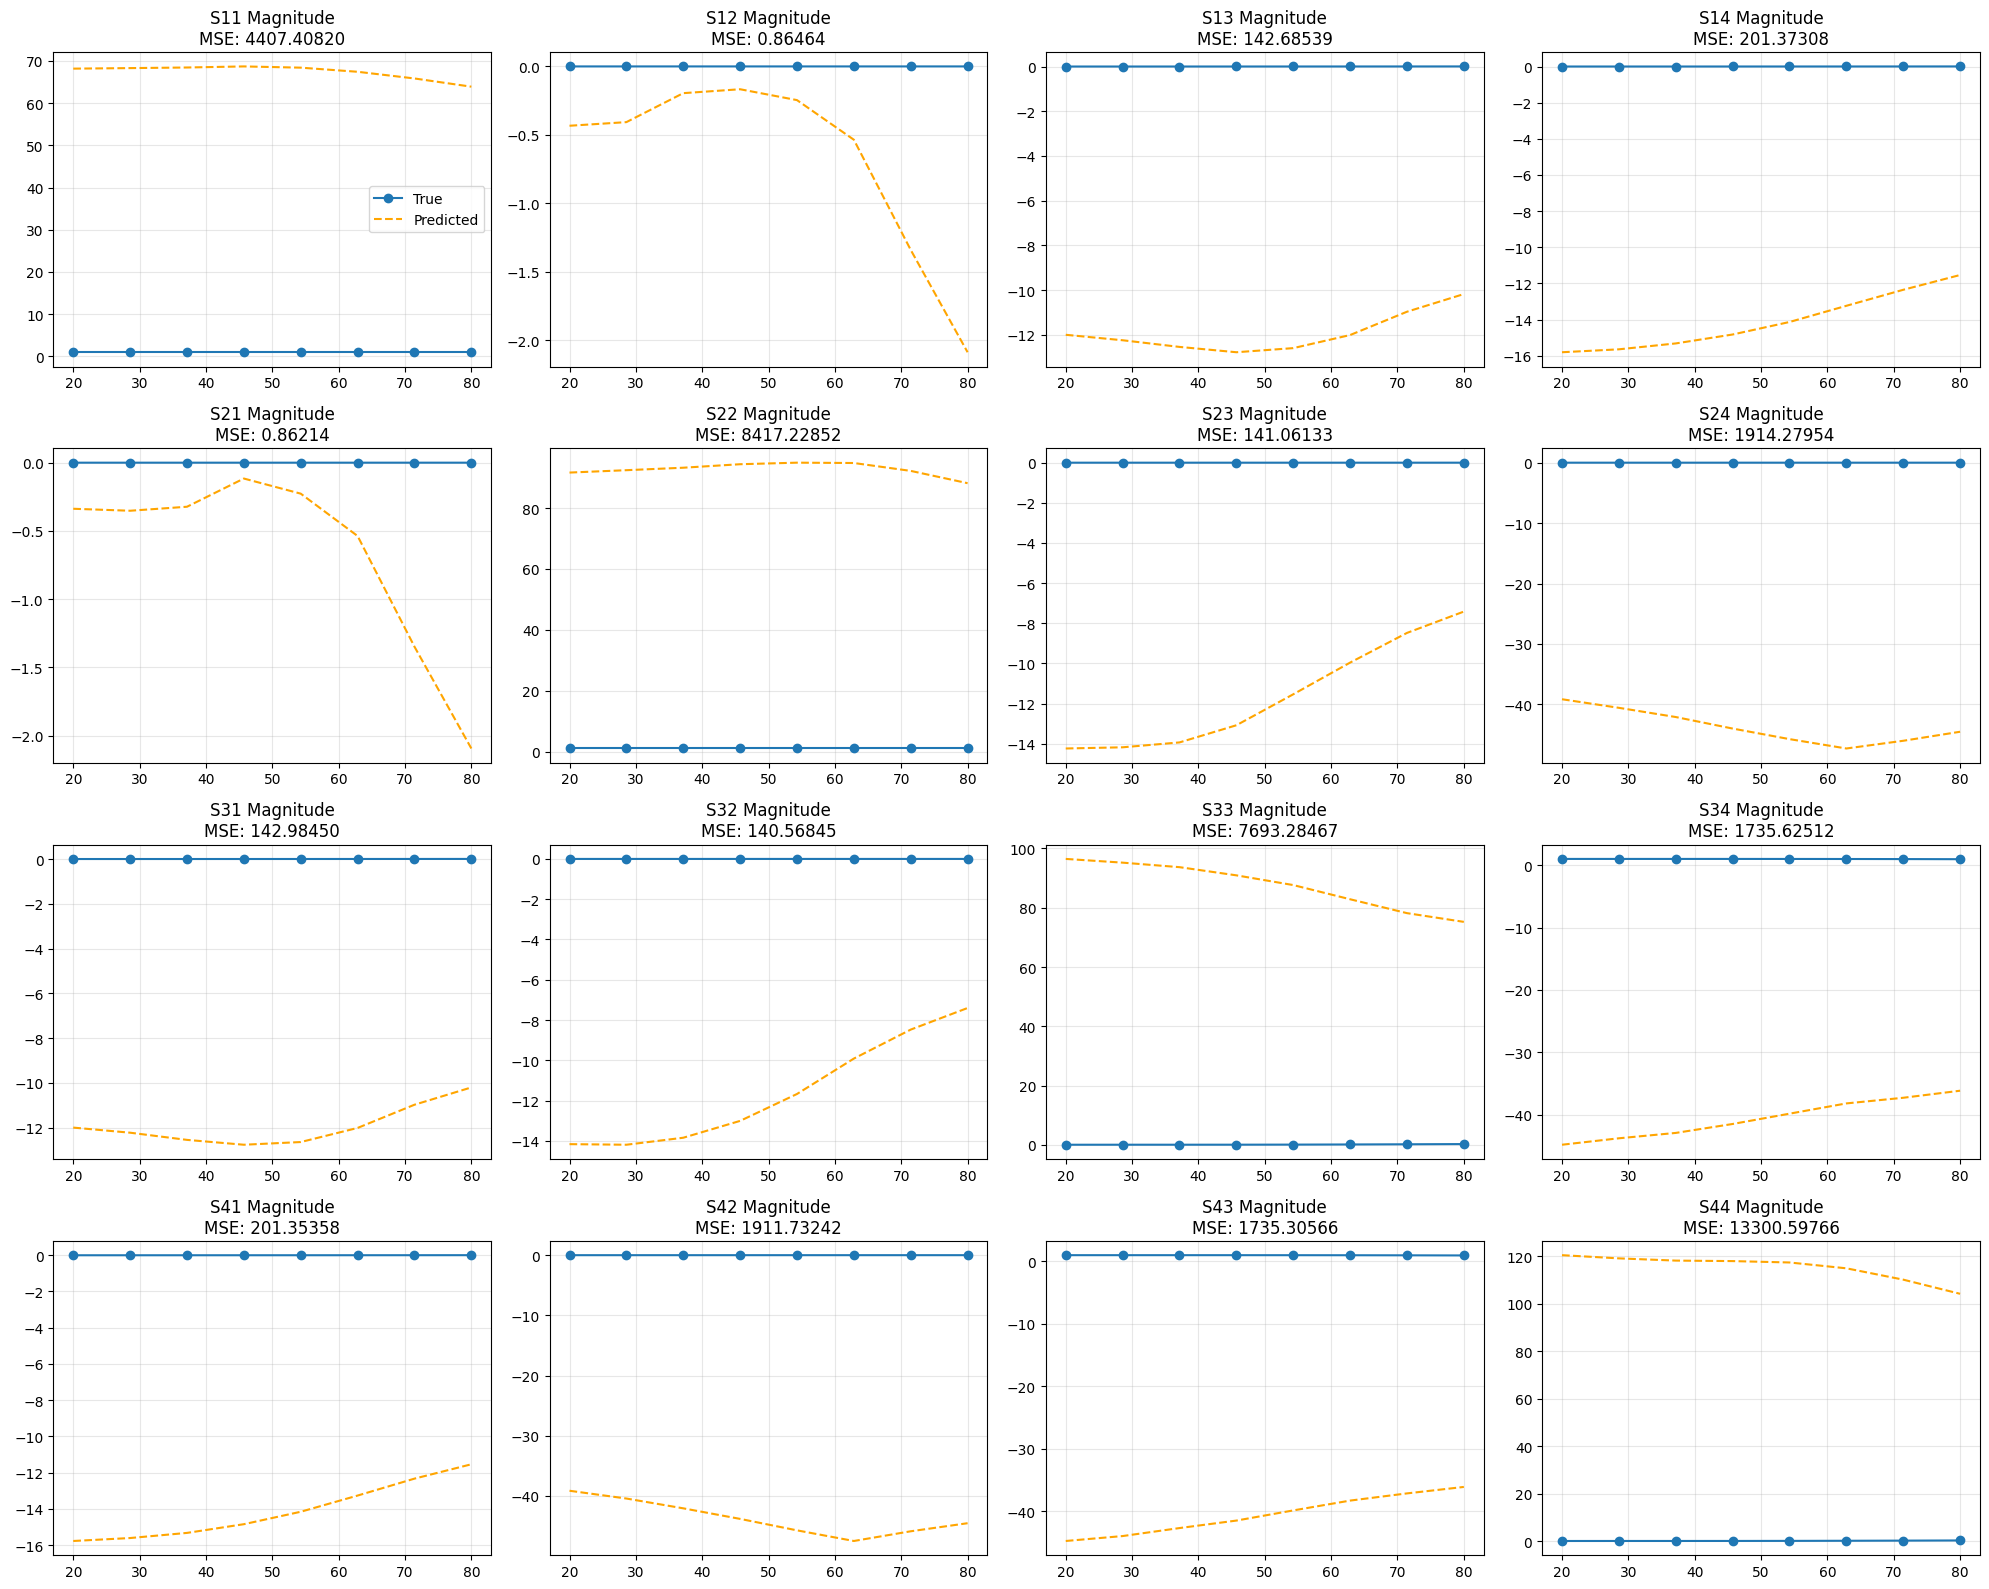

In [ ]:
import matplotlib.pyplot as plt

# 1. Set model to evaluation mode
model.eval()

# 2. Pick a sample from your test tensor
sample_idx = 
input_tensor = test_X[sample_idx].unsqueeze(0).to(device) # Add batch dimension
true_output = test_Y[sample_idx].cpu().numpy()

# 3. Get prediction
with torch.no_grad():
    pred_output = model(input_tensor).cpu().numpy().flatten()

# 4. Define your frequency centers (the x-axis)
# These should match the 'centers' calculated in your files_to_tensor function
num_intervals = 8 # 2^3
# You can grab these from one of your data processing steps
freq_axis = np.linspace(20, 80, num_intervals)

s_params = [
    'S11', 'S12', 'S13', 'S14',
    'S21', 'S22', 'S23', 'S24',
    'S31', 'S32', 'S33', 'S34',
    'S41', 'S42', 'S43', 'S44'
]

fig, axes = plt.subplots(4, 4, figsize=(20, 16))
axes = axes.flatten()

for i, name in enumerate(s_params):
    # Magnitude is at column 2*i in the original 32-column 'data'
    col_idx = 2 * i 
    
    # Extract the 8 points across the 256-vector using a stride of 32
    # 
    y_true_sampled = true_output[col_idx::32]
    y_pred_sampled = pred_output[col_idx::32]
    
    # Calculate MSE for this specific parameter
    mse = np.mean((y_true_sampled - y_pred_sampled)**2)
    
    axes[i].plot(freq_axis, y_true_sampled, 'o-', label='True', color='tab:blue')
    axes[i].plot(freq_axis, y_pred_sampled, '--', label='Predicted', color='orange')
    
    axes[i].set_title(f"{name} Magnitude\nMSE: {mse:.5f}")
    axes[i].grid(True, alpha=0.3)
    if i == 0: axes[i].legend()

plt.tight_layout()
plt.show()

In [28]:

def plot_spectrometer_results(y_true, y_pred, freq_centers):
    # There are 16 S-parameters (S11, S12, S13, S14, S21... S44)
    # Each has a Mag and Phase column = 32 columns total
    s_names = ['S11', 'S12', 'S13', 'S14', 'S21', 'S22', 'S23', 'S24', 
               'S31', 'S32', 'S33', 'S34', 'S41', 'S42', 'S43', 'S44']
    
    fig, axes = plt.subplots(8, 4, figsize=(20, 25)) # 8 rows to separate Mag and Phase
    axes = axes.flatten()

    for i, s_name in enumerate(s_names):
        # column_idx for Mag is 2*i, Phase is 2*i + 1
        mag_col = 2 * i
        phase_col = 2 * i + 1
        
        # Extract the 8 points using strides of 32
        true_mag = y_true[mag_col::32]
        pred_mag = y_pred[mag_col::32]
        
        true_phase = y_true[phase_col::32]
        pred_phase = y_pred[phase_col::32]
        
        # Plot Magnitude (Even rows in the grid)
        ax_m = axes[2*i]
        ax_m.plot(freq_centers, true_mag, 'o-', label='True')
        ax_m.plot(freq_centers, pred_mag, '--', label='Pred')
        ax_m.set_title(f"{s_name} |MAG|")
        
        # Plot Phase (Odd rows in the grid)
        ax_p = axes[2*i + 1]
        ax_p.plot(freq_centers, true_phase, 's-', color='green', label='True')
        ax_p.plot(freq_centers, pred_phase, '--', color='red', label='Pred')
        ax_p.set_title(f"{s_name} ∠ (deg)")

    plt.tight_layout()
    plt.show()
plot_spectrometer_results(true_np, pred_np, )

<function __main__.plot_spectrometer_results(y_true, y_pred, freq_centers)>

In [169]:
def file_to_tensor(x_paths, y_paths,input_path, output_path, n=3):
    all_x = []
    all_y = []
    
    num_intervals = 2 ** n
    x_data = pd.read_csv(os.path.join(input_path, x_paths), header=None).T.values
    all_x.append(x_data.flatten())
    
    # --- Process Output (Frequency Sweep) ---
    df = pd.read_csv(os.path.join(output_path,y_paths), sep=",", skiprows=1)
    # Clean non-numeric rows
    df = df[pd.to_numeric(df.iloc[:, 0], errors="coerce").notna()]
    
    freqs = df.iloc[:, 0].astype(float).to_numpy()
    data  = df.iloc[:, 1:33].astype(float).to_numpy() # 32 columns of data

    # Define sampling points across the frequency spectrum
    edges   = np.linspace(freqs.min(), freqs.max(), num_intervals + 1)
    centers = 0.5 * (edges[:-1] + edges[1:])

    # Find the index of the frequency closest to each center
    # 
    idxs = np.abs(freqs[:, None] - centers[None, :]).argmin(axis=0)
    
    # Select those specific rows and flatten
    y_data = data[idxs].flatten()
    all_y.append(y_data)
        

    
    return torch.tensor(np.array(all_x), dtype=torch.float32), \
           torch.tensor(np.array(all_y), dtype=torch.float32)

In [170]:
input_path =  r"C:\Users\mhenr\Documents\Github\spectrometer-nn\holePunch\Training_Diplex_Cookie_Batch_500_500f_1\Training_Diplex_Cookie_Batch_500_500f_1\geometries"
input_files = [f for f in os.listdir(input_path) if f.endswith('dip_cookie_geom_500_0003.csv')]
output_path = r"C:\Users\mhenr\Documents\Github\spectrometer-nn\holePunch\Training_Diplex_Cookie_Batch_500_500f_1\Training_Diplex_Cookie_Batch_500_500f_1\QR_S_Data"
output_files = [f for f in os.listdir(output_path) if f.endswith('dip_cookie_500_0003.csv')]
# input_file = r"C:\Users\mhenr\Documents\Github\spectrometer-nn\holePunch\Training_Diplex_Cookie_Batch_500_500f_1\Training_Diplex_Cookie_Batch_500_500f_1\geometries\dip_cookie_geom_500_0003.csv"
# output_file = r"C:\Users\mhenr\Documents\Github\spectrometer-nn\holePunch\Training_Diplex_Cookie_Batch_500_500f_1\Training_Diplex_Cookie_Batch_500_500f_1\QR_S_Data\dip_cookie_geom_500_0003.csv"

print(input_files)
print(output_files)
input_tensor, output_tensor = file_to_tensor(input_files[0], output_files[0], input_path, output_path)


['dip_cookie_geom_500_0003.csv']
['dip_cookie_500_0003.csv']


In [175]:
#normalizing the data

x_min = input_tensor.min(dim=0, keepdim=True).values
x_max = input_tensor.max(dim=0, keepdim=True).values

# 2. Add a tiny constant (epsilon) to prevent division by zero 
# (in case a coordinate is exactly the same in every file)
eps = 1e-7

# 3. Apply the transformation: (x - min) / (max - min)


In [176]:
input_tensor = (input_tensor - x_min) / (x_max - x_min + eps)

# train_X = (train_X - x_min) / (x_max - x_min + eps)



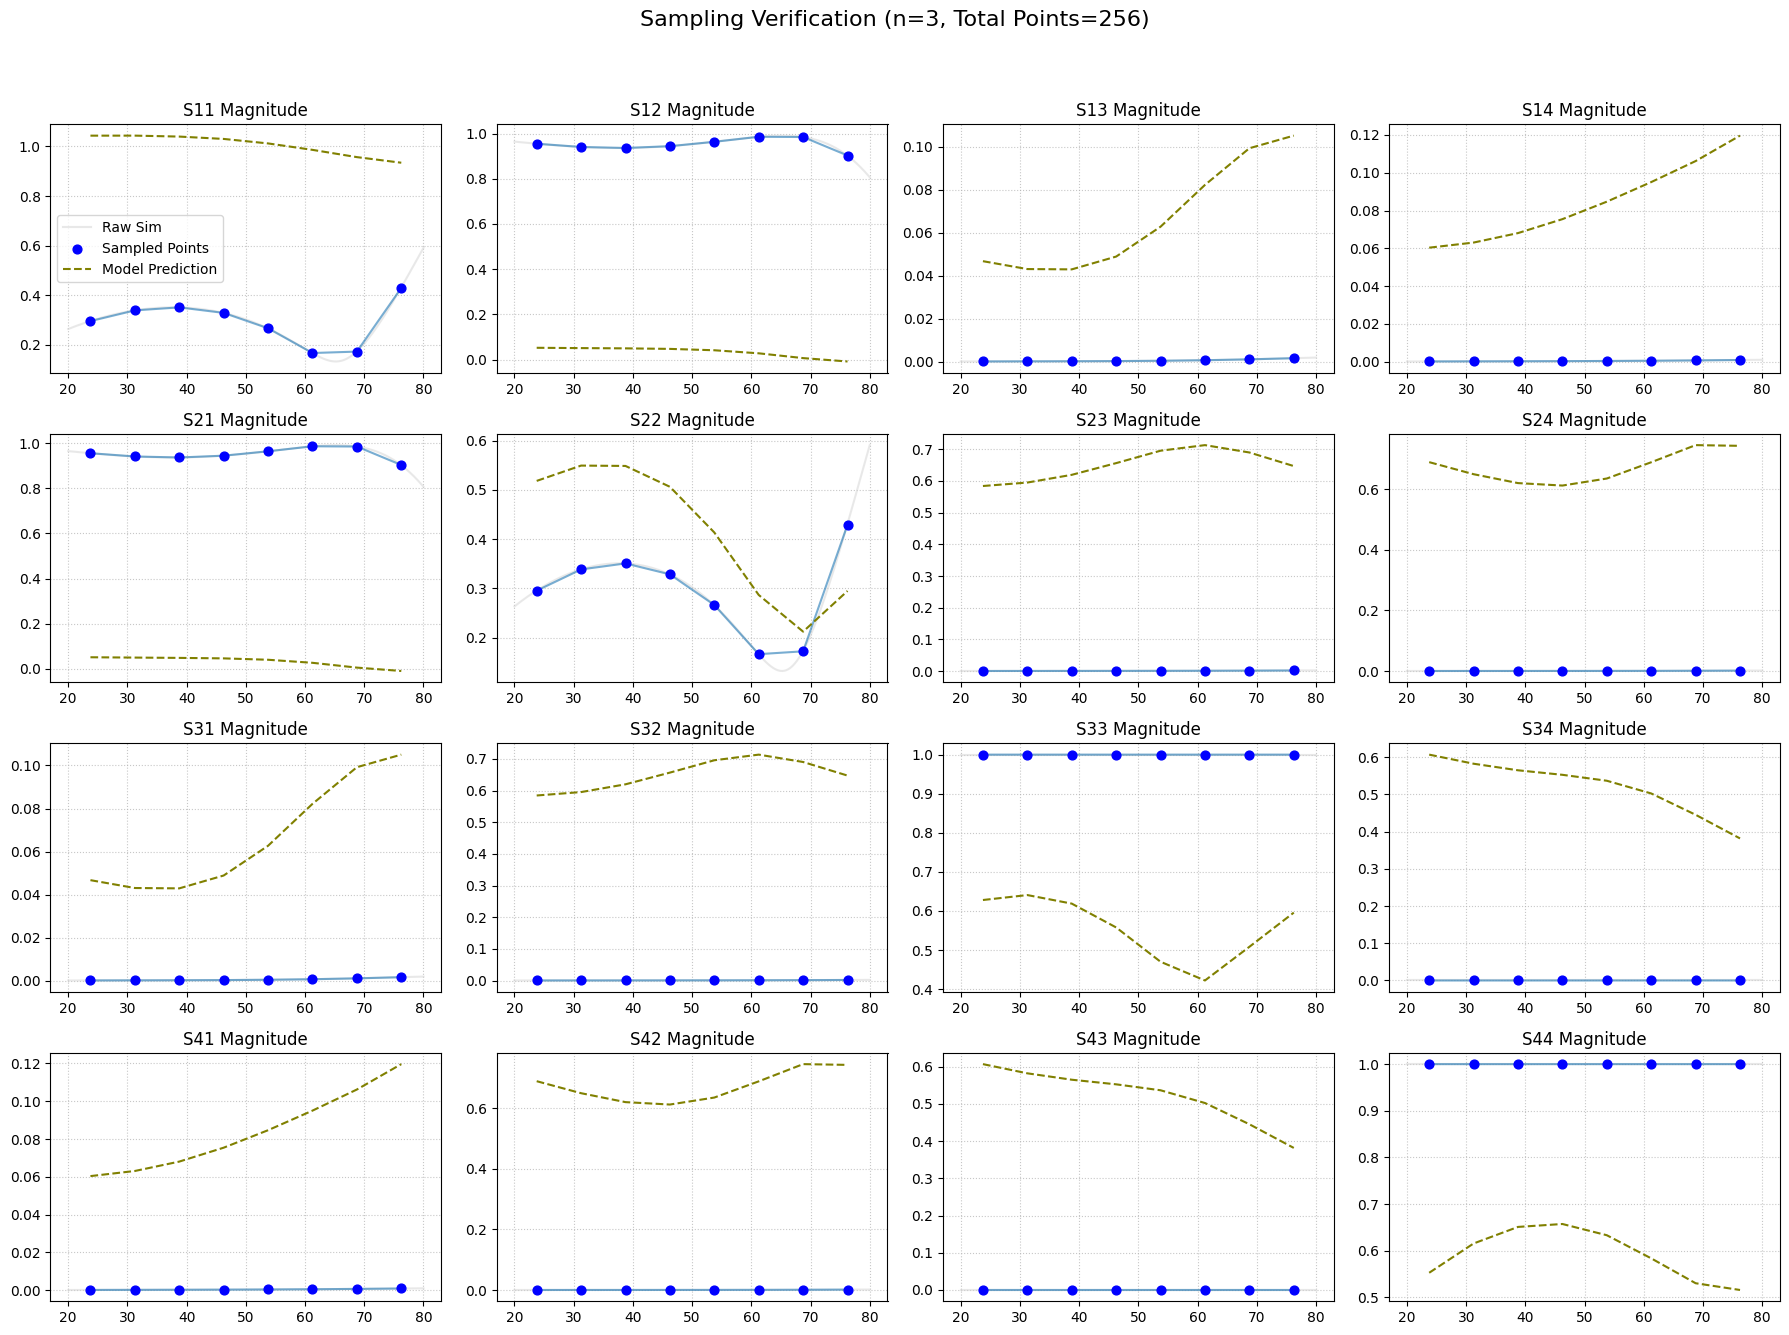

In [177]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import os

def visualize_sampled_data(output_file_path, n=3):
    # 1. Load the raw data
    df = pd.read_csv(output_file_path, sep=",", skiprows=1)
    df = df[pd.to_numeric(df.iloc[:, 0], errors="coerce").notna()]
    
    freqs_raw = df.iloc[:, 0].astype(float).to_numpy()
    data_raw  = df.iloc[:, 1:33].astype(float).to_numpy() 

    # 2. Your Sampling Logic
    num_intervals = 2 ** n
    edges   = np.linspace(freqs_raw.min(), freqs_raw.max(), num_intervals + 1)
    centers = 0.5 * (edges[:-1] + edges[1:])
    
    # Finding nearest indices
    idxs = np.abs(freqs_raw[:, None] - centers[None, :]).argmin(axis=0)
    
    # This is what your model actually "sees" after flattening
    sampled_data_matrix = data_raw[idxs] # Shape: (8, 32)
    y_vector = sampled_data_matrix.flatten() # Shape: (256,)



    #model
    model = FCNet(
    input_dim = 300,
    output_dim = 256,
    n_fc=6,
    dropout_p=0.3
    )
    model.load_state_dict(torch.load("best_model.pt", weights_only=True))
    model.eval()

    with torch.no_grad():
            # Get prediction
            prediction = model(input_tensor)
            
            # Move to CPU and numpy
            y_pred_vector = prediction.cpu().numpy().flatten()


    # 3. Plotting Setup (4x4 grid for 16 S-parameters)
    s_params = ['S11', 'S12', 'S13', 'S14', 'S21', 'S22', 'S23', 'S24', 
                'S31', 'S32', 'S33', 'S34', 'S41', 'S42', 'S43', 'S44']
    
    fig, axes = plt.subplots(4, 4, figsize=(18, 14))
    axes = axes.flatten()
    
    for i, name in enumerate(s_params):
        # Column for Magnitude is 0, 2, 4... (2*i)
        col_idx = 2 * i
        
        # Extract the sampled points from the flattened vector (stride 32)
        # 
        sampled_curve = y_vector[col_idx::32]
        pred_curve  = y_pred_vector[col_idx::32]
        # Plot the Raw Simulation Data (High resolution)
        axes[i].plot(freqs_raw, data_raw[:, col_idx], color='lightgray', label='Raw Sim', alpha=0.5)
        
        # Plot the Sampled Points (What the NN learns)
        axes[i].scatter(centers, sampled_curve, color='blue', s=40, label='Sampled Points', zorder=3)
        axes[i].plot(centers, sampled_curve, '-', alpha=0.6)
        

        axes[i].plot(centers, pred_curve, color='olive', linestyle='--', marker='', label='Model Prediction', zorder=3)
        axes[i].set_title(f"{name} Magnitude")
        axes[i].grid(True, linestyle=':', alpha=0.7)
        if i == 0: axes[i].legend()

    plt.suptitle(f"Sampling Verification (n={n}, Total Points={len(y_vector)})", fontsize=16)
    plt.tight_layout(rect=[0, 0.03, 1, 0.95])
    plt.show()

# Run it on one of your files
example_file = r"C:\Users\mhenr\Documents\Github\spectrometer-nn\holePunch\Training_Diplex_Cookie_Batch_500_500f_1\Training_Diplex_Cookie_Batch_500_500f_1\QR_S_Data\dip_cookie_500_0003.csv"
visualize_sampled_data(example_file)

In [4]:
import matplotlib.pyplot as plt
import numpy as np
import torch

model = FCNet(
    input_dim = 300,
    output_dim = 256,
    n_fc=6,
    dropout_p=0.3
)
model.load_state_dict(torch.load("best_model.pt", weights_only=True))


def plot_model_only(sample_idx, n=3):
    model.eval()

    # --- Run model ---
    with torch.no_grad():
        x = test_X[sample_idx].unsqueeze(0).to(device)
        y_pred = model(x).cpu().numpy().flatten()

    num_intervals = 2 ** n  # should be 8

    s_params = [
        'S11','S12','S13','S14',
        'S21','S22','S23','S24',
        'S31','S32','S33','S34',
        'S41','S42','S43','S44'
    ]

    fig, axes = plt.subplots(4, 4, figsize=(18, 14))
    axes = axes.flatten()

    # Dummy x-axis: index 0..7 (frequency order only)
    x_axis = np.arange(num_intervals)

    for i, name in enumerate(s_params):
        col_idx = 2 * i  # magnitude column

        # Correct reconstruction from flattened vector
        pred_curve = np.array([
            y_pred[k * 32 + col_idx]
            for k in range(num_intervals)
        ])

        axes[i].plot(
            x_axis,
            pred_curve,
            marker='x',
            linestyle='--'
        )

        axes[i].set_title(f"{name} (model only)")
        axes[i].set_xlabel("Sample index (freq order)")
        axes[i].grid(True, linestyle=':', alpha=0.6)

    plt.suptitle(f"Model Output Only — Sample #{sample_idx}", fontsize=16)
    plt.tight_layout(rect=[0, 0.03, 1, 0.95])
    plt.show()

plot_model_only(123)


NameError: name 'test_X' is not defined

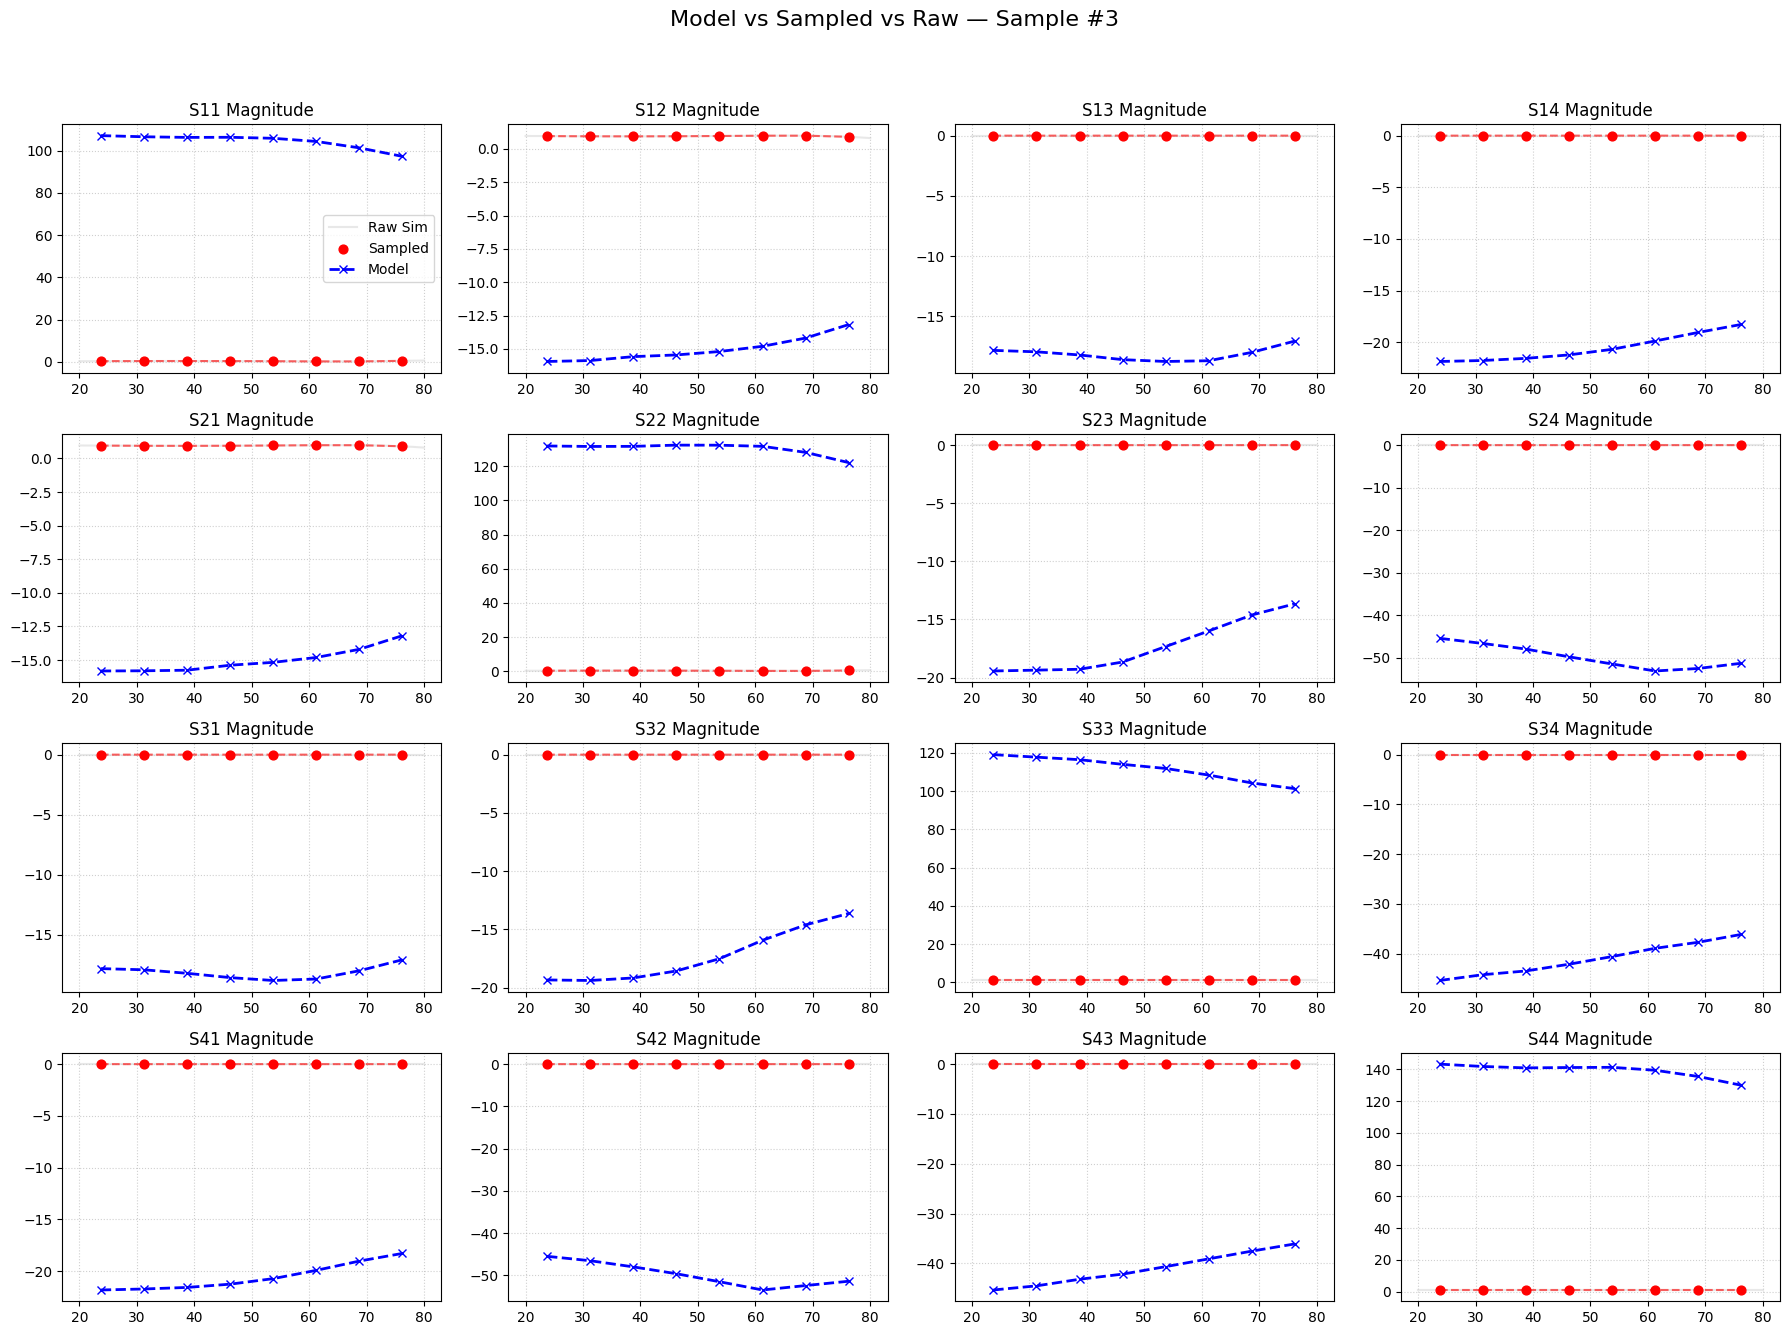

In [92]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch

def visualize_model_vs_data(sample_idx, csv_path, n=3):
    model.eval()

    # -------- MODEL OUTPUT --------
    with torch.no_grad():
        x = test_X[sample_idx].unsqueeze(0).to(device)
        y_pred = model(x).cpu().numpy().flatten()

    # -------- LOAD RAW DATA --------
    df = pd.read_csv(csv_path, sep=",", skiprows=1)
    df = df[pd.to_numeric(df.iloc[:, 0], errors="coerce").notna()]

    freqs_raw = df.iloc[:, 0].astype(float).to_numpy()
    data_raw  = df.iloc[:, 1:33].astype(float).to_numpy()

    # -------- SAMPLING (same as training) --------
    num_intervals = 2 ** n
    edges   = np.linspace(freqs_raw.min(), freqs_raw.max(), num_intervals + 1)
    centers = 0.5 * (edges[:-1] + edges[1:])

    idxs = np.abs(freqs_raw[:, None] - centers[None, :]).argmin(axis=0)
    sampled_matrix = data_raw[idxs]              # (8, 32)
    y_true = sampled_matrix.flatten()             # (256,)

    # -------- PLOTTING --------
    s_params = [
        'S11','S12','S13','S14',
        'S21','S22','S23','S24',
        'S31','S32','S33','S34',
        'S41','S42','S43','S44'
    ]

    fig, axes = plt.subplots(4, 4, figsize=(18, 14))
    axes = axes.flatten()

    for i, name in enumerate(s_params):
        col_idx = 2 * i  # magnitude column

        # True sampled curve
        true_curve = y_true[col_idx::32]

        # Model predicted curve
        pred_curve = np.array([
            y_pred[k * 32 + col_idx]
            for k in range(num_intervals)
        ])

        # Raw sim
        axes[i].plot(
            freqs_raw,
            data_raw[:, col_idx],
            color='lightgray',
            alpha=0.5,
            label='Raw Sim'
        )

        # Sampled points (ground truth)
        axes[i].scatter(
            centers,
            true_curve,
            color='red',
            s=40,
            zorder=3,
            label='Sampled'
        )
        axes[i].plot(centers, true_curve, 'r--', alpha=0.6)

        # Model prediction
        axes[i].plot(
            centers,
            pred_curve,
            marker='x',
            linestyle='--',
            linewidth=2,
            color='blue',
            label='Model'
        )

        axes[i].set_title(f"{name} Magnitude")
        axes[i].grid(True, linestyle=':', alpha=0.6)
        if i == 0:
            axes[i].legend()

    plt.suptitle(f"Model vs Sampled vs Raw — Sample #{sample_idx}", fontsize=16)
    plt.tight_layout(rect=[0, 0.03, 1, 0.95])
    plt.show()
example_file = r"C:\Users\mhenr\Documents\Github\spectrometer-nn\holePunch\Training_Diplex_Cookie_Batch_500_500f_1\Training_Diplex_Cookie_Batch_500_500f_1\QR_S_Data\dip_cookie_500_0003.csv"
visualize_model_vs_data(3, example_file)

In [5]:
import os
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from matplotlib import gridspec


device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# -------------------------
# 0) Settings
# -------------------------
data_root = "."
n = 3
num_intervals = 2**n
s_labels = ["S11", "S12", "S13", "S14", "S22", "S23", "S24", "S33", "S34", "S44"]

model_path = "best_model.pt"
latent_dim = 128
pred_output_dim = num_intervals * 10 * 2

out_dir = "viz_top_samples_with_input_128"
os.makedirs(out_dir, exist_ok=True)

# -------------------------
# Your top-5 results
# -------------------------
TOP_VARIANCE = [
    {"sample_idx": 895, "label": "S23", "score": 0.165255},
    {"sample_idx": 946, "label": "S13", "score": 0.138433},
    {"sample_idx": 619, "label": "S34", "score": 0.135634},
    {"sample_idx": 369, "label": "S24", "score": 0.134992},
    {"sample_idx": 734, "label": "S11", "score": 0.133497},
]
TOP_P2P = [
    {"sample_idx": 73,  "label": "S14", "p2p": 0.993707},
    {"sample_idx": 78,  "label": "S23", "p2p": 0.98614},
    {"sample_idx": 3,   "label": "S13", "p2p": 0.958378},
    {"sample_idx": 877, "label": "S13", "p2p": 0.954927},
    {"sample_idx": 946, "label": "S13", "p2p": 0.933405},
]

# -------------------------
# 1) Helpers
# -------------------------
def load_clean_csv(csv_path: str) -> pd.DataFrame:
    df = pd.read_csv(csv_path, sep=",", skiprows=1)
    df = df[pd.to_numeric(df.iloc[:, 0], errors="coerce").notna()]
    df.iloc[:, 0] = df.iloc[:, 0].astype(float)
    return df.reset_index(drop=True)

def compute_sample_idxs(freqs: np.ndarray, num_intervals: int):
    edges = np.linspace(freqs.min(), freqs.max(), num_intervals + 1)
    centers = 0.5 * (edges[:-1] + edges[1:])
    idxs = np.abs(freqs[:, None] - centers[None, :]).argmin(axis=0)
    return idxs, centers

def wrap_angle_deg_torch(angle_deg: torch.Tensor) -> torch.Tensor:
    """Wrap degrees to [-180, 180] using smooth trig map."""
    ang_rad = torch.deg2rad(angle_deg)
    return torch.rad2deg(torch.atan2(torch.sin(ang_rad), torch.cos(ang_rad)))

def unwrap_angle_deg_np(angle_deg: np.ndarray) -> np.ndarray:
    """Unwrap degrees to a continuous curve (numpy)."""
    return np.rad2deg(np.unwrap(np.deg2rad(angle_deg)))

def wrap_angle_deg_np(angle_deg: np.ndarray) -> np.ndarray:
    """Wrap degrees to [-180, 180] (numpy)."""
    return (angle_deg + 180) % 360 - 180

# -------------------------
# 2) Load dataset & model
# -------------------------
dataset = DiplexDataset(
    data_root=data_root,
    n=n,
    transform=None,
    augment_factor=1
)

model = FCNet(
    input_dim = 300,
    output_dim = 256,
    n_fc=6,
    dropout_p=0.3
)
ckpt = torch.load(model_path, map_location=device)
model.load_state_dict(ckpt["model_state_dict"])
model.eval()

# -------------------------
# 3) Core visualization (colors match your ORIGINAL script)
# -------------------------
def visualize_sample(sample_idx: int, metric_name: str, focus_label: str, score: float):
    print(f"[VIZ] sample #{sample_idx} | {metric_name} | focus={focus_label}")

    # ---- Load sample
    x, y_true = dataset[sample_idx]
    x_batch = x.unsqueeze(0).to(device)

    with torch.no_grad():
        x_recon, y_pred, mu, logvar, z = model(x_batch, noise_scale=1.0)
        y_pred = y_pred.detach().cpu().squeeze()

    # ---- Load CSV
    csv_path = r"C:\Users\mhenr\Documents\Github\spectrometer-nn\holePunch\Training_Diplex_Cookie_Batch_500_500f_2\Training_Diplex_Cookie_Batch_500_500f_2\geometries\dip_cookie_geom_500_{sample_idx}.csv"
    df = load_clean_csv(csv_path)

    freqs = df.iloc[:, 0].to_numpy()
    idxs, _ = compute_sample_idxs(freqs, num_intervals)
    freqs_sampled = freqs[idxs]

    y_true = y_true.view(num_intervals, 10, 2)
    y_pred = y_pred.view(num_intervals, 10, 2)

    # model outputs
    y_pred_mag_pos = F.softplus(y_pred[:, :, 0])  # (num_intervals, 10)
    y_pred_ang_deg = y_pred[:, :, 1]             # (num_intervals, 10)

    all_mag_vals = []
    for lbl in s_labels:
        col = f"MAG[{lbl}]"
        if col in df.columns:
            all_mag_vals.append(df[col].to_numpy())
    all_mag_vals = np.concatenate(all_mag_vals) if len(all_mag_vals) else np.array([0.0, 1.0])
    mag_min = float(np.min(all_mag_vals))
    mag_max = float(np.max(all_mag_vals))

    # -------------------------
    # Figure layout
    #   row 0: input
    #   rows 1..10: S11..S44
    # -------------------------
    fig = plt.figure(figsize=(14, 20))
    gs = gridspec.GridSpec(
        11, 2,
        height_ratios=[1.3] + [1]*10,
        hspace=0.45,
        wspace=0.35
    )

    fig.suptitle(
        f"Sample #{sample_idx} | {metric_name} | focus={focus_label} | score={score:.4g}",
        fontsize=16,
        y=0.99
    )

    # ---- Input geometry
    ax_img = fig.add_subplot(gs[0, :])
    x_np = x.squeeze().cpu().numpy()
    if x_np.ndim == 3:
        x_np = x_np[0]
    ax_img.imshow(x_np, cmap="gray", interpolation="nearest")
    ax_img.set_title("Input Geometry", fontsize=12, pad=4)
    ax_img.axis("off")

    # -------------------------
    # Plot S-parameters
    # -------------------------
    for i, label in enumerate(s_labels):
        mag_col = f"MAG[{label}]"
        ang_col = f"ANG[{label}]"

        if mag_col not in df.columns or ang_col not in df.columns:
            continue

        true_mag_sampled = df.iloc[idxs][mag_col].to_numpy()
        true_ang_sampled = df.iloc[idxs][ang_col].to_numpy()

        # ===== MAG  =====
        ax_mag = fig.add_subplot(gs[i+1, 0])
        ax_mag.plot(df.iloc[:, 0], df[mag_col], lw=1.2, color="C0")
        ax_mag.scatter(freqs_sampled, true_mag_sampled, s=18, color="C0", zorder=5)
        ax_mag.plot(
            freqs_sampled,
            y_pred_mag_pos[:, i].numpy(),
            "--o",
            lw=1.4,
            markersize=3.5,
            color="orange",
            zorder=6
        )

        mse_mag = float(np.mean((y_pred_mag_pos[:, i].numpy() - true_mag_sampled) ** 2))
        ax_mag.set_title(f"{label} |MAG| (MSE={mse_mag:.3g})", fontsize=9, pad=2)
        ax_mag.set_ylim(mag_min - 0.05, mag_max + 0.05)
        ax_mag.grid(alpha=0.25)

        # ===== ANG (unwrap target+pred → wrap to [-180,180]) =====
        ax_ang = fig.add_subplot(gs[i+1, 1])

        true_ang_unwrap = unwrap_angle_deg_np(true_ang_sampled)
        true_ang_plot = wrap_angle_deg_np(true_ang_unwrap)

        pred_ang_np = y_pred_ang_deg[:, i].numpy()
        pred_ang_unwrap = unwrap_angle_deg_np(pred_ang_np)
        pred_ang_plot = wrap_angle_deg_np(pred_ang_unwrap)

        ax_ang.plot(df.iloc[:, 0], df[ang_col], lw=1.2, color="C2")
        ax_ang.scatter(freqs_sampled, true_ang_plot, s=18, color="C2", zorder=5)
        ax_ang.plot(
            freqs_sampled,
            pred_ang_plot,
            "--o",
            lw=1.4,
            markersize=3.5,
            color="red",
            zorder=6
        )

        # MSE using minimal angular difference
        diff_wrapped = wrap_angle_deg_np(pred_ang_plot - true_ang_plot)
        mse_ang = float(np.mean(diff_wrapped ** 2))

        ax_ang.set_title(f"{label} ∠ (MSE={mse_ang:.3g})", fontsize=9, pad=2)
        ax_ang.set_ylim(-180, 180)
        ax_ang.grid(alpha=0.25)

    # -------------------------
    # Save
    # -------------------------
    out_path = os.path.join(out_dir, f"{metric_name}_sample{sample_idx}_focus{focus_label}.png")
    plt.tight_layout(rect=[0, 0, 1, 0.985])
    plt.savefig(out_path, dpi=300, bbox_inches="tight")
    plt.close(fig)

    print(f"[INFO] saved → {out_path}")

# -------------------------
# 4) Run batch
# -------------------------
for r in TOP_VARIANCE:
    visualize_sample(
        r["sample_idx"],
        metric_name="VAR",
        focus_label=r["label"],
        score=r["score"]
    )

for r in TOP_P2P:
    visualize_sample(
        r["sample_idx"],
        metric_name="P2P",
        focus_label=r["label"],
        score=r["p2p"]
    )

print("\n[DONE] All visualizations generated.")


NameError: name 'DiplexDataset' is not defined

In [75]:
data = DiplexDataset(data_root=r".\Training_Diplex_Cookie_Batch_500_500f_1", n = 5)

C:\Users\mhenr\Documents\Github\spectrometer-nn\holePunch\Training_Diplex_Cookie_Batch_500_500f_1\Training_Diplex_Cookie_Batch_500_500f_1\geometries


In [79]:
df = pd.read_csv(r'C:/Users/mhenr/Documents/Github/spectrometer-nn/holePunch/Training_Diplex_Cookie_Batch_500_500f_1/Training_Diplex_Cookie_Batch_500_500f_1/QR_S_Data/dip_cookie_geom_500_0124.csv')

FileNotFoundError: [Errno 2] No such file or directory: 'C:/Users/mhenr/Documents/Github/spectrometer-nn/holePunch/Training_Diplex_Cookie_Batch_500_500f_1/Training_Diplex_Cookie_Batch_500_500f_1/QR_S_Data/dip_cookie_geom_500_0124.csv'

In [76]:
data[123]

FileNotFoundError: [Errno 2] No such file or directory: 'C:\\Users\\mhenr\\Documents\\Github\\spectrometer-nn\\holePunch\\Training_Diplex_Cookie_Batch_500_500f_1\\Training_Diplex_Cookie_Batch_500_500f_1\\QR_S_Data\\dip_cookie_geom_500_0124.csv'

In [74]:
from torch.utils.data import Dataset, DataLoader, random_split
import glob


class DiplexDataset(Dataset):
    def __init__(self, data_root, n=5, transform=None):
        self.n = n
        self.transform = transform
        self.max_resolution = (1, 80, 80) 

        # input/output directory paths
        self.input_dir = r"C:\Users\mhenr\Documents\Github\spectrometer-nn\holePunch\Training_Diplex_Cookie_Batch_500_500f_1\Training_Diplex_Cookie_Batch_500_500f_1\geometries"
        self.output_dir = r"C:\Users\mhenr\Documents\Github\spectrometer-nn\holePunch\Training_Diplex_Cookie_Batch_500_500f_1\Training_Diplex_Cookie_Batch_500_500f_1\QR_S_Data"
        print(self.input_dir)
        # pair input and output files by filename
        self.input_files = sorted(glob.glob(os.path.join(self.input_dir, "*.csv")))
        self.output_files = [
            os.path.join(self.output_dir, os.path.basename(f)) for f in self.input_files
        ]

    def __len__(self):
        return len(self.input_files)

    def __getitem__(self, idx):
        # ----- input -----
        input_path = self.input_files[idx]
        input_arr = np.loadtxt(input_path, delimiter=",").astype(np.float32)

        input_img = torch.from_numpy(input_arr)  # (H, W)

        input_img = torch.nn.functional.interpolate(input_img.unsqueeze(0).unsqueeze(0),
                                                    size=self.max_resolution[1:],
                                                    mode="nearest",).squeeze(0) #resize to (1, 80, 80)

        if self.transform:
            input_img = self.transform(input_img)

        

        # ----- output -----
        output_path = self.output_files[idx]
        # ----- output -----

        df = pd.read_csv(output_path, sep=",", skiprows=1)

        df = df[pd.to_numeric(df.iloc[:, 0], errors="coerce").notna()]

        
        freqs = df.iloc[:, 0].astype(float).to_numpy()
        data  = df.iloc[:, 1:33].astype(float).to_numpy()


        print(f"\n[DEBUG] Output file: {os.path.basename(output_path)}")
        print(f"  rows={len(freqs)}, cols(data)={data.shape[1]}")
        print(f"  first 5 freqs: {freqs[:5]}")
        print(f"  first row (8 vals): {data[0][:8]}")

        num_intervals = 2 ** self.n
        edges   = np.linspace(freqs.min(), freqs.max(), num_intervals + 1)
        centers = 0.5 * (edges[:-1] + edges[1:])

        # vectorized nearest pick per interval center
        idxs = np.abs(freqs[:, None] - centers[None, :]).argmin(axis=0)
        output_vec = torch.tensor(data[idxs].reshape(-1), dtype=torch.float32)  # (2^n*32,)



        num_intervals = 2 ** self.n
        f_min, f_max = freqs.min(), freqs.max()
        interval_edges = np.linspace(f_min, f_max, num_intervals + 1)
        centers = 0.5 * (interval_edges[:-1] + interval_edges[1:])

        # pick row nearest to each interval center of the 2^n intervals
        chosen_rows = []
        for c in centers:
            idx_closest = np.argmin(np.abs(freqs - c))
            chosen_rows.append(data[idx_closest])
        chosen_rows = np.stack(chosen_rows, axis=0)  # (2^n, 32)

        output_vec = torch.tensor(chosen_rows.flatten(), dtype=torch.float32)  # (2^n*32,)

        return input_img, output_vec